# Определение параметров атмосферы экзопланеты по профилю поглощения

У близких к своей звезде планет-гигантов верхняя атмосфера "раздувается" и испаряется.
Когда такая планета проходит по диску звезды (транзит), её протяжённая атмосфера
поглощает часть звёздного света в линии метастабильного гелия **He I 10830 Å**.
Форма получившегося **профиля поглощения** (зависимость поглощения от доплеровской
скорости) зависит от физических условий в системе.

**Задача:** по профилю поглощения (101 точка на сетке скоростей от −5 до +5)
предсказать четыре параметра, с которыми была запущена физическая модель:

| Параметр | Тип | Смысл | Метрика |
|---|---|---|---|
| `XUVInt` | int | поток ионизующего излучения звезды | MAPE |
| `Helium` | float | отношение содержания гелия к водороду | MAPE |
| `Msw` | float (~1e11…1e14) | темп потери массы звёздного ветра | MAPE по log10 |
| `H2a` | bool | состояние водорода на нижней границе (молекулярный/атомарный) | ROC-AUC |

Каждый пример — папка вида `XUV11Msw10e11He0p0800H1` с двумя файлами:
* `Absorption.dat` — таблица `VV FullAbs ResPart Thermal` (нам нужны первые два столбца);
* `parameters.txt` — параметры запуска модели (из них берём 4 таргета).

Ниже — решение на основе простой одномерной свёрточной сети (1D CNN).

## 1. Загрузка данных

Профили посчитаны на слегка разных сетках скоростей, поэтому приводим все
к одной общей сетке `[-5, 5]` с шагом 0.1 линейной интерполяцией.
Один повреждённый прогон (обрезанная сетка) отбрасываем.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available()
          else "cpu")
print("device:", DEVICE)

device: mps


In [2]:
DATA_DIR = "../new_dataset_V3"          # папка с датасетом (лежит рядом с ноутбуком)
GRID = np.arange(-5.0, 5.0 + 1e-9, 0.1)  # общая сетка доплеровских скоростей, 101 точка


def load_run(path):
    """Читает одну папку: возвращает (словарь параметров, профиль на общей сетке)."""
    params = {}
    with open(os.path.join(path, "parameters.txt")) as f:
        for line in f:
            parts = line.split()
            if len(parts) >= 2:
                params[parts[0]] = parts[1]

    arr = np.loadtxt(os.path.join(path, "Absorption.dat"), skiprows=1)
    vv, absorption = arr[:, 0], arr[:, 1]      # столбцы VV и FullAbs
    if vv[-1] - vv[0] < 5:                     # обрезанный (битый) профиль
        return None
    profile = np.interp(GRID, vv, absorption, left=0.0, right=0.0)
    return params, profile


profiles, targets = [], []
for name in sorted(os.listdir(DATA_DIR)):
    path = os.path.join(DATA_DIR, name)
    if not os.path.isdir(path):
        continue
    result = load_run(path)
    if result is None:
        continue
    params, profile = result
    profiles.append(profile)
    targets.append([
        float(params["XUVInt"]),
        float(params["Helium"]),
        float(params["Msw"]),
        int(params["H2a"]),
    ])

profiles = np.array(profiles, dtype=np.float32)          # (N, 101)
targets = np.array(targets, dtype=np.float64)            # (N, 4)
print("профилей:", profiles.shape, " таргетов:", targets.shape)

профилей: (613, 101)  таргетов: (613, 4)


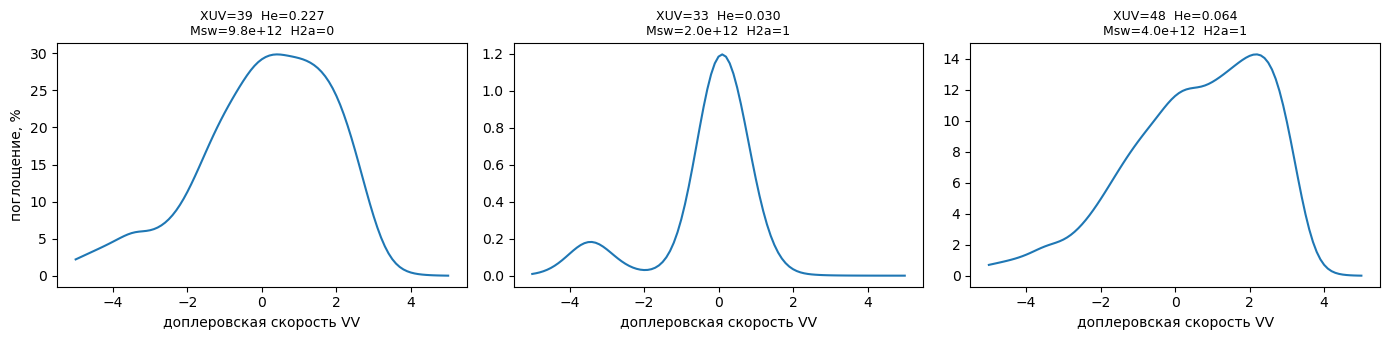

In [3]:
# посмотрим на несколько профилей
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=False)
rng = np.random.default_rng(0)
for ax, i in zip(axes, rng.choice(len(profiles), 3, replace=False)):
    ax.plot(GRID, 100 * profiles[i])
    xuv, he, msw, h2a = targets[i]
    ax.set_title(f"XUV={xuv:g}  He={he:.3f}\nMsw={msw:.1e}  H2a={int(h2a)}", fontsize=9)
    ax.set_xlabel("доплеровская скорость VV")
axes[0].set_ylabel("поглощение, %")
plt.tight_layout()
plt.show()

## 2. Подготовка данных

Три непрерывных таргета положительны и меняются на порядки, поэтому предсказываем
их **логарифмы** — так сеть учится проще, а метрика MAPE считается после обратного
преобразования `10**pred`. Логарифмы дополнительно стандартизуем
(вычитаем среднее, делим на стандартное отклонение) по обучающей выборке.

Вход сети — **два канала**:
1. сам профиль, отмасштабированный к ~[0, 1];
2. его логарифм (стандартизованный) — в крыльях линии поглощение на порядки
   меньше, чем в пике, и в логарифмическом масштабе сеть "видит" форму крыльев,
   которая несёт много информации о параметрах.

Для обучающей выборки используем простую **аугментацию** — гауссов шум,
пропорциональный амплитуде профиля: это имитирует шум реальных наблюдений
и не даёт сети переобучиться на ~600 примерах.

In [4]:
# логарифмируем непрерывные таргеты: log10(XUVInt), log10(Helium), log10(Msw)
y_reg = np.log10(targets[:, :3])              # (N, 3)
y_cls = targets[:, 3].astype(np.float32)      # (N,)

idx_train, idx_val = train_test_split(
    np.arange(len(profiles)), test_size=0.2, random_state=SEED, stratify=y_cls)

# статистики нормировки считаем ТОЛЬКО по train
y_mean = y_reg[idx_train].mean(axis=0)
y_std = y_reg[idx_train].std(axis=0)
x_scale = profiles[idx_train].max()           # масштаб профилей


def make_input(profile):
    """Два канала: линейный профиль и его логарифм."""
    linear = profile / x_scale
    log = np.log10(profile + 1e-6)
    log = (log - log.mean()) / (log.std() + 1e-9)
    return np.stack([linear, log])            # (2, 101)


print("train:", len(idx_train), " val:", len(idx_val))
print("y_mean:", y_mean.round(3), " y_std:", y_std.round(3))

train: 490  val: 123
y_mean: [ 1.287 -1.292 12.928]  y_std: [0.387 0.43  0.717]


In [5]:
class ProfileDataset(Dataset):
    def __init__(self, indices, augment=False):
        self.indices = indices
        self.augment = augment

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        profile = profiles[idx]
        if self.augment:                       # шум ~0.5% от амплитуды профиля
            profile = profile + np.random.normal(0, 0.005 * profile.max(),
                                                 size=profile.shape)
            profile = np.clip(profile, 1e-7, None)
        y = (y_reg[idx] - y_mean) / y_std      # нормированные логарифмы
        return (torch.tensor(make_input(profile), dtype=torch.float32),  # (2, 101)
                torch.tensor(y, dtype=torch.float32),
                torch.tensor(y_cls[idx]))


train_loader = DataLoader(ProfileDataset(idx_train, augment=True),
                          batch_size=64, shuffle=True)
val_loader = DataLoader(ProfileDataset(idx_val), batch_size=256)

## 3. Модель

Простая одномерная свёрточная сеть: три свёрточных блока извлекают локальные
особенности профиля (форму пика, крылья линии). Вместо глобального пулинга
используем `Flatten` — так сеть сохраняет информацию о **положении** деталей
профиля по оси скоростей (например, доплеровский сдвиг пика важен для `Msw`).
Две "головы" выдают:
* 3 числа — нормированные логарифмы `XUVInt`, `Helium`, `Msw`;
* 1 число — логит класса `H2a`.

Обучаем обе головы одновременно: суммарный лосс = MSE (регрессия) + BCE (классификация).

In [6]:
class ProfileCNN(nn.Module):
    def __init__(self, channels=(64, 128, 128)):
        super().__init__()
        blocks, in_ch = [], 2                  # 2 входных канала
        for out_ch in channels:
            blocks += [
                nn.Conv1d(in_ch, out_ch, kernel_size=5, padding=2),
                nn.BatchNorm1d(out_ch),
                nn.ReLU(),
                nn.MaxPool1d(2),
            ]
            in_ch = out_ch
        blocks.append(nn.Flatten())
        self.encoder = nn.Sequential(*blocks)
        flat = in_ch * (101 // 2 // 2 // 2)    # 128 каналов × 12 позиций
        self.head_reg = nn.Sequential(
            nn.Linear(flat, 256), nn.ReLU(), nn.Dropout(0.2), nn.Linear(256, 3))
        self.head_cls = nn.Sequential(
            nn.Linear(flat, 128), nn.ReLU(), nn.Dropout(0.2), nn.Linear(128, 1))

    def forward(self, x):                      # x: (B, 2, 101)
        h = self.encoder(x)                    # (B, flat)
        return self.head_reg(h), self.head_cls(h).squeeze(-1)


model = ProfileCNN().to(DEVICE)
print(sum(p.numel() for p in model.parameters()), "параметров")

715588 параметров


## 4. Обучение

In [7]:
EPOCHS = 400
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
mse, bce = nn.MSELoss(), nn.BCEWithLogitsLoss()

history = {"train": [], "val": []}
best_val, best_state = float("inf"), None

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    for x, y, c in train_loader:
        x, y, c = x.to(DEVICE), y.to(DEVICE), c.to(DEVICE)
        pred_reg, pred_cls = model(x)
        loss = mse(pred_reg, y) + bce(pred_cls, c)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(x)
    scheduler.step()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x, y, c in val_loader:
            x, y, c = x.to(DEVICE), y.to(DEVICE), c.to(DEVICE)
            pred_reg, pred_cls = model(x)
            val_loss += (mse(pred_reg, y) + bce(pred_cls, c)).item() * len(x)

    train_loss /= len(idx_train)
    val_loss /= len(idx_val)
    history["train"].append(train_loss)
    history["val"].append(val_loss)
    if val_loss < best_val:
        best_val = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    if (epoch + 1) % 50 == 0:
        print(f"эпоха {epoch + 1:3d}: train {train_loss:.4f}  val {val_loss:.4f}")

model.load_state_dict(best_state)   # возвращаем лучшие по валидации веса
print(f"лучший val loss: {best_val:.4f}")

эпоха  50: train 0.3656  val 0.3769


эпоха 100: train 0.1766  val 0.3087


эпоха 150: train 0.1310  val 0.2266


эпоха 200: train 0.1082  val 0.2342


эпоха 250: train 0.0820  val 0.2145


эпоха 300: train 0.0701  val 0.2401


эпоха 350: train 0.0601  val 0.2083


эпоха 400: train 0.0630  val 0.2171
лучший val loss: 0.1810


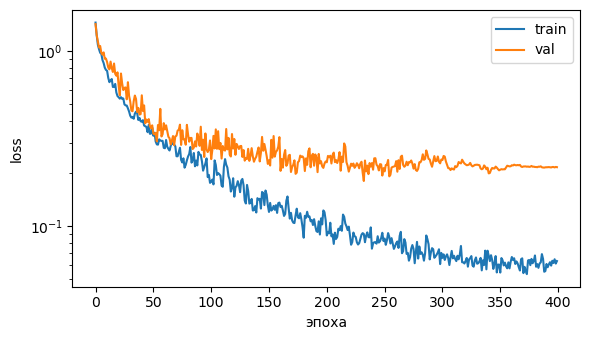

In [8]:
plt.figure(figsize=(6, 3.5))
plt.plot(history["train"], label="train")
plt.plot(history["val"], label="val")
plt.xlabel("эпоха")
plt.ylabel("loss")
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Оценка качества

Возвращаем предсказания в исходный масштаб (`10**`) и считаем метрики:
MAPE для непрерывных параметров (для `Msw` — по `log10`, т.к. сама величина
меняется на 3 порядка) и ROC-AUC для `H2a`.

In [9]:
model.eval()
preds_reg, preds_cls = [], []
with torch.no_grad():
    for x, _, _ in val_loader:
        pred_reg, pred_cls = model(x.to(DEVICE))
        preds_reg.append(pred_reg.cpu().numpy())
        preds_cls.append(torch.sigmoid(pred_cls).cpu().numpy())

pred_log = np.concatenate(preds_reg) * y_std + y_mean   # обратно в log10
pred_proba = np.concatenate(preds_cls)

true_log = y_reg[idx_val]
true_lin = 10 ** true_log
pred_lin = 10 ** pred_log


def mape(t, p):
    return 100 * np.mean(np.abs((p - t) / t))


print(f"XUVInt  MAPE = {mape(true_lin[:, 0], pred_lin[:, 0]):6.1f}%")
print(f"Helium  MAPE = {mape(true_lin[:, 1], pred_lin[:, 1]):6.1f}%")
print(f"logMsw  MAPE = {mape(true_log[:, 2], pred_log[:, 2]):6.1f}%")
auc = roc_auc_score(y_cls[idx_val], pred_proba)
acc = accuracy_score(y_cls[idx_val], pred_proba > 0.5)
print(f"H2a     ROC-AUC = {auc:.3f}, accuracy = {acc:.3f}")

XUVInt  MAPE =   22.1%


Helium  MAPE =   20.7%
logMsw  MAPE =    1.3%
H2a     ROC-AUC = 0.996, accuracy = 0.992


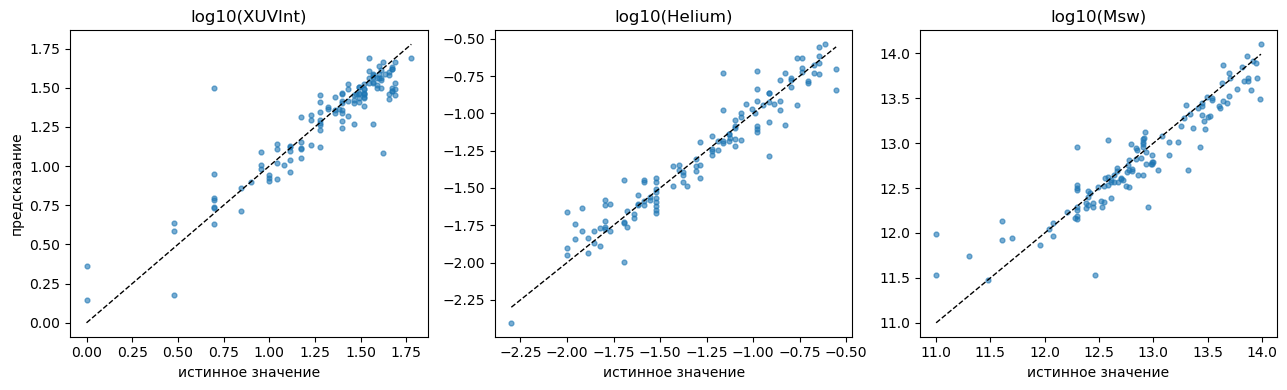

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
names = ["log10(XUVInt)", "log10(Helium)", "log10(Msw)"]
for k, (ax, name) in enumerate(zip(axes, names)):
    ax.scatter(true_log[:, k], pred_log[:, k], s=12, alpha=0.6)
    lims = [true_log[:, k].min(), true_log[:, k].max()]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_xlabel("истинное значение")
    ax.set_title(name)
axes[0].set_ylabel("предсказание")
plt.tight_layout()
plt.show()

## 6. Что можно улучшить

Это базовое решение — есть много направлений для роста качества:

* **Ансамбли** — обучить несколько сетей с разной инициализацией и усреднить
  (или выдавать несколько вариантов ответа: задача обратная и неоднозначная —
  разные комбинации `XUVInt` и `Helium` дают похожие профили);
* **Архитектура** — попробовать трансформер/механизм внимания, residual-связи,
  подобрать глубину и ширину сети;
* **Аугментации** — более реалистичный шум, изменение спектрального разрешения;
* **Кросс-валидация** — надёжнее оценивать качество на маленькой выборке;
* **Отдельные модели** на каждый параметр вместо одной многоголовой.